In [47]:
import sys
import os
from pathlib import Path

_project_root = Path('..').resolve()
os.environ.setdefault('DATA_CATALOG_PATH', str(_project_root / 'data' / 'catalog'))
sys.path.insert(0, str(_project_root))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from cyber_trader.data.catalog import get_catalog
from cyber_trader.config import get_settings
from cyber_trader.indicators.factor_engine import (
    BollingerFactor, RSIFactor, StochasticMRFactor,
    EMACrossoverFactor, MACDFactor, MomentumFactor,
    KeltnerBreakoutFactor, StochasticFactor, VolumeMomentumFactor,
)

catalog  = get_catalog()
settings = get_settings()
print(f'Catalog: {settings.data_catalog_path}')
print('Available extra factor classes:')
print('  EMACrossoverFactor, MACDFactor, MomentumFactor,')
print('  KeltnerBreakoutFactor, StochasticFactor, VolumeMomentumFactor')

Catalog: /Users/bytedance/github_personal/cyber_trader/data/catalog
Available extra factor classes:
  EMACrossoverFactor, MACDFactor, MomentumFactor,
  KeltnerBreakoutFactor, StochasticFactor, VolumeMomentumFactor


In [48]:
# ═══════════════════════════════════════════════
#  修改这里来切换时间段 / 品种
# ═══════════════════════════════════════════════
INSTRUMENT = 'ETH-USDT-SWAP.OKX'
TIMEFRAME  = '15m'           # 15m | 1h | 4h | 1d
START      = '2026-06-01'
END        = '2026-06-06'

# MR 基础因子参数
BB_PERIOD     = 20
BB_K          = 2.0
BB_WEIGHT     = 0.45
RSI_PERIOD    = 14
RSI_WEIGHT    = 0.35
STOCH_K       = 14
STOCH_D       = 3
STOCH_SLOW    = 3
STOCH_WEIGHT  = 0.20

# 入场阈值
LONG_THRESHOLD  =  0.50
SHORT_THRESHOLD = -0.50

# ═══════════════════════════════════════════════
#  自定义额外因子 — 解开注释即可启用
#  每个因子会自动在图表下方新增一个得分面板
#  label: 面板标题 / 列名
#  instance: 因子实例（直接 new 出来）
#  color: 面板线条颜色（HEX）
# ═══════════════════════════════════════════════
EXTRA_FACTORS = [
     {"label": "EMA(9,21)",   "instance": EMACrossoverFactor(fast=9, slow=21, weight=1.0),     "color": "#80CBC4"},
     {"label": "MACD(12,26)", "instance": MACDFactor(fast=12, slow=26, weight=1.0),            "color": "#FFAB91"},
    # {"label": "MOM(10)",     "instance": MomentumFactor(period=10, weight=1.0),               "color": "#FFF176"},
    # {"label": "KC_BREAK",    "instance": KeltnerBreakoutFactor(period=20, k=2.0, weight=1.0), "color": "#CE93D8"},
    # {"label": "STOCH(14)",   "instance": StochasticFactor(period_k=14, weight=1.0),           "color": "#80DEEA"},
     {"label": "VOLMOM(20)",  "instance": VolumeMomentumFactor(period=20, weight=0.5),         "color": "#A5D6A7"},
]

# ═══════════════════════════════════════════════
#  回测模拟参数
# ═══════════════════════════════════════════════
BACKTEST_ENABLED  = True   # 是否在图上叠加模拟交易标记
ATR_PERIOD        = 14     # ATR 计算周期
ATR_SL_MULT       = 1.5    # SL = ATR × ATR_SL_MULT
ATR_RR_RATIO      = 2.0    # TP = SL_dist × ATR_RR_RATIO
MAX_HOLD_BARS     = 32     # 超过此 bar 数强制平仓（0 = 不限）
EXIT_SCORE_RATIO  = 0.15   # score 退出阈值 = 入场阈值 × 此比例（均值回归归位信号）
# ═══════════════════════════════════════════════

In [49]:
from cyber_trader.data.okx_downloader import timeframe_to_bar_type
from nautilus_trader.indicators.volatility import AverageTrueRange

BAR_TYPE = timeframe_to_bar_type(INSTRUMENT, TIMEFRAME)
start_ts = pd.Timestamp(START, tz='UTC')
end_ts   = pd.Timestamp(END,   tz='UTC') + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
start_ns, end_ns = int(start_ts.value), int(end_ts.value)

print(f'Instrument : {INSTRUMENT}  [{TIMEFRAME}]')
print(f'Range      : {start_ts.date()}  →  {end_ts.date()}')

bb_f    = BollingerFactor(period=BB_PERIOD, k=BB_K,        weight=BB_WEIGHT)
rsi_f   = RSIFactor(period=RSI_PERIOD,                     weight=RSI_WEIGHT)
stch_f  = StochasticMRFactor(period_k=STOCH_K, period_d=STOCH_D,
                              slowing=STOCH_SLOW,           weight=STOCH_WEIGHT)
_atr    = AverageTrueRange(ATR_PERIOD)

# 初始化 extra 因子实例（从配置中取出，预热时也一并 update）
_extra_instances = [ef['instance'] for ef in EXTRA_FACTORS]

print('Loading bars from catalog...')
all_bars = catalog.bars([BAR_TYPE])
print(f'Total in catalog: {len(all_bars):,}')

rows = []
for bar in all_bars:
    bb_f.update(bar)
    rsi_f.update(bar)
    stch_f.update(bar)
    _atr.update_raw(bar.high.as_double(), bar.low.as_double(), bar.close.as_double())
    for ef_inst in _extra_instances:
        ef_inst.update(bar)

    # BB 原始值（上中下轨）
    bb_upper = bb_f._bb.upper  if bb_f.is_initialized else None
    bb_mid   = bb_f._bb.middle if bb_f.is_initialized else None
    bb_lower = bb_f._bb.lower  if bb_f.is_initialized else None

    # RSI 原始值（0-100）
    rsi_raw  = rsi_f._rsi.value if rsi_f.is_initialized else None

    # Stochastic %K 原始值（0-100）
    stk_raw  = stch_f._stoch.value_k if stch_f.is_initialized else None

    # 复合因子得分（加权平均，仅含 3 基础因子）
    total_w = sum(abs(f.weight) for f in [bb_f, rsi_f, stch_f] if f.is_initialized)
    composite = (
        sum(f.weighted_score() for f in [bb_f, rsi_f, stch_f] if f.is_initialized) / total_w
        if total_w > 0 else 0.0
    )

    if start_ns <= bar.ts_event <= end_ns:
        row = {
            'ts':        pd.Timestamp(bar.ts_event, unit='ns', tz='UTC'),
            'open':      bar.open.as_double(),
            'high':      bar.high.as_double(),
            'low':       bar.low.as_double(),
            'close':     bar.close.as_double(),
            'bb_upper':  bb_upper,
            'bb_mid':    bb_mid,
            'bb_lower':  bb_lower,
            'bb_score':  bb_f.score()   if bb_f.is_initialized   else 0.0,
            'rsi_raw':   rsi_raw,
            'rsi_score': rsi_f.score()  if rsi_f.is_initialized  else 0.0,
            'stk_raw':   stk_raw,
            'stk_score': stch_f.score() if stch_f.is_initialized else 0.0,
            'composite': composite,
            'atr':       _atr.value if _atr.initialized else float('nan'),
        }
        # extra 因子得分，每个单独一列（列名 = label）
        for ef in EXTRA_FACTORS:
            ei = ef['instance']
            row[ef['label']] = ei.score() if ei.is_initialized else 0.0
        rows.append(row)

if not rows:
    raise ValueError(f'No bars found for {INSTRUMENT} [{TIMEFRAME}] in {START} ~ {END}.')

df = pd.DataFrame(rows).set_index('ts')
print(f'Plotting    : {len(df):,} bars  [{df.index[0]}  →  {df.index[-1]}]')
if EXTRA_FACTORS:
    print(f'Extra factors: {[ef["label"] for ef in EXTRA_FACTORS]}')
df.head()

Instrument : ETH-USDT-SWAP.OKX  [15m]
Range      : 2026-06-01  →  2026-06-06
Loading bars from catalog...
Total in catalog: 50,078
Plotting    : 542 bars  [2026-06-01 00:00:00+00:00  →  2026-06-06 15:15:00+00:00]
Extra factors: ['EMA(9,21)', 'MACD(12,26)', 'VOLMOM(20)']


,open,high,low,close,bb_upper,bb_mid,bb_lower,bb_score,rsi_raw,rsi_score,stk_raw,stk_score,composite,atr,"EMA(9,21)","MACD(12,26)",VOLMOM(20)
ts,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00+00:00,2006.40,2015.00,2005.33,2010.99,2016.622915,2006.090667,1995.558419,-0.465175,0.583963,0.988321,42.319872,0.153603,0.167304,6.331429,0.009809,0.100183,1.000000
2026-06-01 00:15:00+00:00,2011.00,2016.85,2007.62,2016.14,2016.934731,2006.956000,1996.977269,-0.920358,0.672792,0.986544,57.714919,-0.154298,-0.099730,6.544286,0.017384,0.188687,0.193993
2026-06-01 00:30:00+00:00,2016.13,2020.83,2011.50,2015.15,2017.329329,2007.938833,1998.548337,-0.767922,0.642370,0.987153,63.286154,-0.265723,-0.053206,7.021429,0.021497,0.229620,-0.557621
2026-06-01 00:45:00+00:00,2015.14,2019.00,2013.69,2014.71,2017.723303,2008.806500,1999.889697,-0.662065,0.627813,0.987444,65.126754,-0.302535,-0.012831,7.132143,0.023618,0.260021,0.171151
2026-06-01 01:00:00+00:00,2014.70,2016.16,2003.60,2004.71,2017.360421,2009.158500,2000.956579,0.542373,0.393785,0.992124,44.569391,0.108612,0.613034,7.730714,0.013890,0.158516,-0.585576


In [50]:
# ── 回测模拟（基于 composite score + ATR SL/TP，复现 MR15m 核心逻辑）───────────
trades = []

if BACKTEST_ENABLED:
    position  = 0      # 0=平仓  1=多头  -1=空头
    entry_i   = None
    entry_px  = None
    sl_px     = None
    tp_px     = None
    bars_held = 0

    long_exit_thr  = LONG_THRESHOLD  * EXIT_SCORE_RATIO
    short_exit_thr = SHORT_THRESHOLD * EXIT_SCORE_RATIO

    prices    = df['close'].values
    scores    = df['composite'].values
    atrs      = df['atr'].values
    n_bars    = len(df)

    for i in range(n_bars):
        price = prices[i]
        score = scores[i]
        atr   = atrs[i] if not math.isnan(atrs[i]) else 0.0

        # ── 持仓检查：SL / TP / MaxHold / 信号退出 ────────────────────────
        if position != 0:
            bars_held += 1
            exit_reason = None

            if position == 1:    # 多头
                if price <= sl_px:
                    exit_reason = 'SL'
                elif price >= tp_px:
                    exit_reason = 'TP'
                elif score < long_exit_thr:
                    exit_reason = 'SIGNAL'
            else:                # 空头
                if price >= sl_px:
                    exit_reason = 'SL'
                elif price <= tp_px:
                    exit_reason = 'TP'
                elif score > short_exit_thr:
                    exit_reason = 'SIGNAL'

            if MAX_HOLD_BARS > 0 and bars_held >= MAX_HOLD_BARS and exit_reason is None:
                exit_reason = 'MAX_HOLD'

            if exit_reason:
                pnl_pct = (price - entry_px) / entry_px * 100 * position
                trades.append({
                    'direction':   'LONG' if position == 1 else 'SHORT',
                    'entry_i':     entry_i,
                    'entry_ts':    df.index[entry_i],
                    'entry_px':    entry_px,
                    'sl_px':       sl_px,
                    'tp_px':       tp_px,
                    'exit_i':      i,
                    'exit_ts':     df.index[i],
                    'exit_px':     price,
                    'exit_reason': exit_reason,
                    'pnl_pct':     pnl_pct,
                })
                position  = 0
                bars_held = 0

        # ── 新信号入场（仅平仓时触发）─────────────────────────────────────
        if position == 0:
            sl_dist = (atr * ATR_SL_MULT) if atr > 0 else price * 0.015
            tp_dist = sl_dist * ATR_RR_RATIO
            if score >= LONG_THRESHOLD:
                position  =  1
                entry_i   = i
                entry_px  = price
                sl_px     = price - sl_dist
                tp_px     = price + tp_dist
                bars_held = 0
            elif score <= SHORT_THRESHOLD:
                position  = -1
                entry_i   = i
                entry_px  = price
                sl_px     = price + sl_dist
                tp_px     = price - tp_dist
                bars_held = 0

    # 期末未平仓
    if position != 0:
        exit_px = prices[-1]
        pnl_pct = (exit_px - entry_px) / entry_px * 100 * position
        trades.append({
            'direction':   'LONG' if position == 1 else 'SHORT',
            'entry_i':     entry_i,
            'entry_ts':    df.index[entry_i],
            'entry_px':    entry_px,
            'sl_px':       sl_px,
            'tp_px':       tp_px,
            'exit_i':      n_bars - 1,
            'exit_ts':     df.index[-1],
            'exit_px':     exit_px,
            'exit_reason': 'OPEN',
            'pnl_pct':     pnl_pct,
        })

    # ── 打印交易明细 ─────────────────────────────────────────────────────
    print(f'模拟交易: {len(trades)} 笔')
    if trades:
        wins      = sum(1 for t in trades if t['pnl_pct'] > 0)
        total_pnl = sum(t['pnl_pct'] for t in trades)
        print(f'胜率: {wins}/{len(trades)} = {wins/len(trades):.1%}   总PnL: {total_pnl:+.2f}%')
        print()
        for idx, t in enumerate(trades, 1):
            sign = '+' if t['pnl_pct'] >= 0 else ''
            print(
                f"#{idx:<2} {t['direction']:<5} "
                f"{str(t['entry_ts'])[:16]} → {str(t['exit_ts'])[:16]}  "
                f"entry={t['entry_px']:.2f}  exit={t['exit_px']:.2f}  "
                f"SL={t['sl_px']:.2f}  TP={t['tp_px']:.2f}  "
                f"{t['exit_reason']:<8} {sign}{t['pnl_pct']:.2f}%"
            )
else:
    print('BACKTEST_ENABLED=False，跳过模拟')

模拟交易: 42 笔
胜率: 13/42 = 31.0%   总PnL: -13.49%

#1  LONG  2026-06-01 01:00 → 2026-06-01 03:15  entry=2004.71  exit=2014.27  SL=1993.11  TP=2027.90  SIGNAL   +0.48%
#2  LONG  2026-06-01 04:00 → 2026-06-01 06:15  entry=2002.32  exit=1985.71  SL=1989.82  TP=2027.33  SL       -0.83%
#3  LONG  2026-06-01 06:15 → 2026-06-01 08:15  entry=1985.71  exit=1975.23  SL=1975.47  TP=2006.19  SL       -0.53%
#4  LONG  2026-06-01 08:15 → 2026-06-01 12:15  entry=1975.23  exit=1986.15  SL=1964.75  TP=1996.20  SIGNAL   +0.55%
#5  LONG  2026-06-01 13:00 → 2026-06-01 15:15  entry=1974.97  exit=1960.86  SL=1963.25  TP=1998.41  SL       -0.71%
#6  LONG  2026-06-01 15:15 → 2026-06-01 17:00  entry=1960.86  exit=1982.89  SL=1943.73  TP=1995.11  SIGNAL   +1.12%
#7  LONG  2026-06-01 22:00 → 2026-06-01 22:45  entry=1989.49  exit=2003.49  SL=1979.68  TP=2009.11  SIGNAL   +0.70%
#8  LONG  2026-06-02 00:45 → 2026-06-02 01:45  entry=1995.52  exit=1979.55  SL=1983.89  TP=2018.78  SL       -0.80%
#9  LONG  2026-06-02 01:45

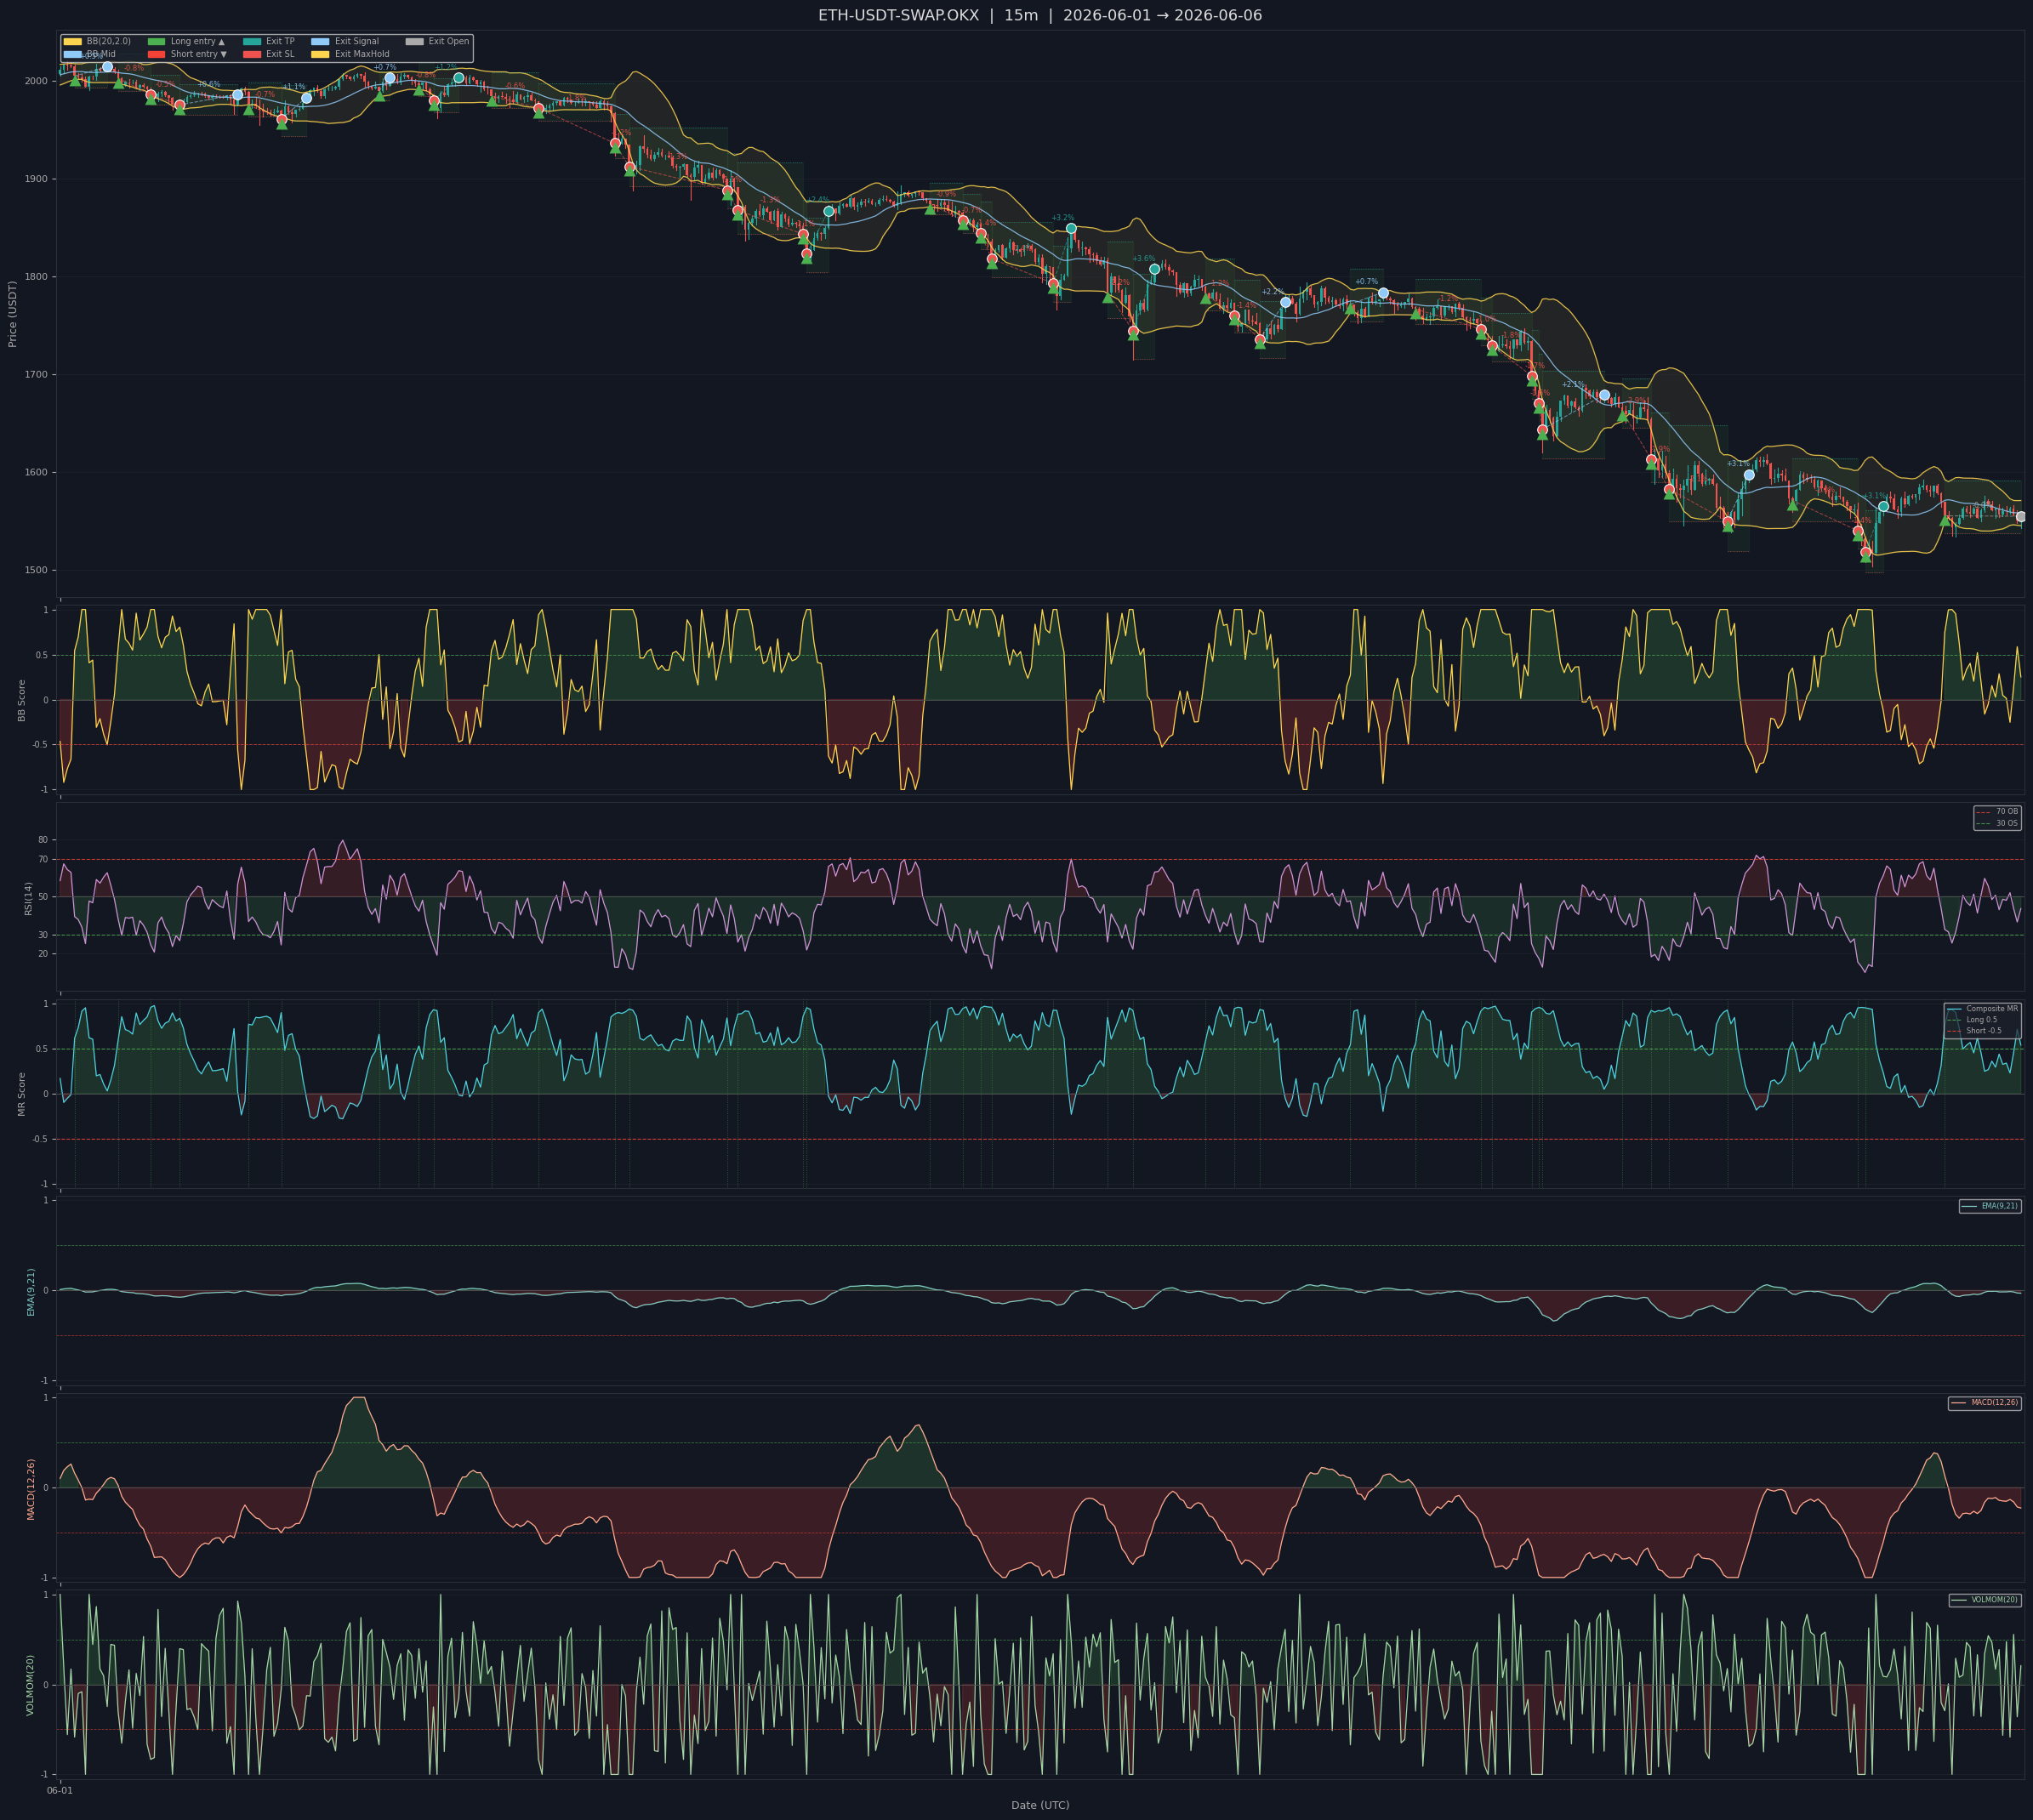

Done — 542 bars  |  Trades=42  Wins=13/42=31.0%  TotalPnL=-13.49%


In [51]:
n = len(df)

# ── X 轴刻度 ─────────────────────────────────────────────────────────────────
_tf_bars = {'15m': 1, '1h': 4, '4h': 16, '1d': 96}
bars_per_day = 96 // _tf_bars.get(TIMEFRAME, 1)

if n <= 120:
    tick_step = max(1, bars_per_day // 2)
elif n <= 500:
    tick_step = bars_per_day * 7
elif n <= 2000:
    tick_step = bars_per_day * 14
else:
    tick_step = bars_per_day * 30

tick_pos    = list(range(0, n, tick_step))
tick_fmt    = '%m-%d' if n <= 2000 else '%Y-%m'
tick_labels = [df.index[i].strftime(tick_fmt) for i in tick_pos]

# ── Layout — 动态行数（4 固定面板 + extra 因子数）─────────────────────────────
n_extra   = len(EXTRA_FACTORS)
n_panels  = 4 + n_extra
h_ratios  = [3, 1, 1, 1] + [1] * n_extra

fig, axes = plt.subplots(
    n_panels, 1,
    figsize=(24, 4 + 2.5 * n_panels),
    sharex=True,
    gridspec_kw={'height_ratios': h_ratios},
)
if n_panels == 1:
    axes = [axes]

ax_c    = axes[0]
ax_bb   = axes[1]
ax_rsi  = axes[2]
ax_comp = axes[3]
ax_extras = list(axes[4:])

fig.patch.set_facecolor('#131722')
for ax in axes:
    ax.set_facecolor('#131722')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2e39')

# ── Candlestick ───────────────────────────────────────────────────────────────
width = 0.6
bull  = '#26a69a'
bear  = '#ef5350'

for i, (ts, row) in enumerate(df.iterrows()):
    color = bull if row['close'] >= row['open'] else bear
    safe_high = min(row['high'], row['close'] * 1.5)
    safe_low  = max(row['low'],  row['close'] * 0.5)
    ax_c.plot([i, i], [safe_low, safe_high], color=color, linewidth=0.8, zorder=1)
    bot = min(row['open'], row['close'])
    h   = max(abs(row['close'] - row['open']), row['close'] * 1e-4)
    ax_c.add_patch(mpatches.Rectangle(
        (i - width / 2, bot), width, h,
        facecolor=color, edgecolor='none', zorder=2
    ))

# ── BB 带叠加在K线上 ──────────────────────────────────────────────────────────
x    = np.arange(n)
bb_u = df['bb_upper'].values.astype(float)
bb_m = df['bb_mid'].values.astype(float)
bb_l = df['bb_lower'].values.astype(float)

ax_c.plot(x, bb_u, color='#FFD54F', linewidth=0.9, alpha=0.85, zorder=3, label=f'BB({BB_PERIOD},{BB_K})')
ax_c.plot(x, bb_m, color='#90CAF9', linewidth=0.9, alpha=0.85, zorder=3, label='BB Mid')
ax_c.plot(x, bb_l, color='#FFD54F', linewidth=0.9, alpha=0.85, zorder=3)
ax_c.fill_between(x, bb_u, bb_l, alpha=0.07, color='#FFD54F', zorder=0)

# ── 在 K 线图上叠加模拟交易 ────────────────────────────────────────────────────
_EXIT_COLORS = {
    'TP':       '#26a69a',
    'SL':       '#ef5350',
    'SIGNAL':   '#90CAF9',
    'MAX_HOLD': '#FFD54F',
    'OPEN':     '#aaaaaa',
}
_price_range  = df['high'].max() - df['low'].min()
_marker_offset = _price_range * 0.008   # 入场标记略偏离收盘价

if BACKTEST_ENABLED and trades:
    for t in trades:
        ei      = t['entry_i']
        xi      = t['exit_i']
        epx     = t['entry_px']
        xpx     = t['exit_px']
        sl      = t['sl_px']
        tp      = t['tp_px']
        is_long = (t['direction'] == 'LONG')
        exc     = _EXIT_COLORS.get(t['exit_reason'], '#aaaaaa')

        # SL / TP 区间阴影（仅在持仓期间）
        ax_c.fill_between(
            [ei, xi], [sl, sl], [tp, tp],
            alpha=0.08,
            color='#4CAF50' if is_long else '#F44336',
            zorder=0,
        )
        # SL / TP 水平线
        ax_c.plot([ei, xi], [sl, sl], color='#ef5350', linewidth=0.7,
                  linestyle=':', alpha=0.6, zorder=3)
        ax_c.plot([ei, xi], [tp, tp], color='#26a69a', linewidth=0.7,
                  linestyle=':', alpha=0.6, zorder=3)

        # 入场箭头：多 ▲（标价格下方）/ 空 ▼（标价格上方）
        if is_long:
            ax_c.scatter(ei, epx - _marker_offset, marker='^', s=100,
                         color='#4CAF50', zorder=7, linewidths=0)
        else:
            ax_c.scatter(ei, epx + _marker_offset, marker='v', s=100,
                         color='#F44336', zorder=7, linewidths=0)

        # 离场标记（圆圈，颜色按离场类型）
        ax_c.scatter(xi, xpx, marker='o', s=70, color=exc,
                     zorder=7, linewidths=0.8, edgecolors='#ffffff')

        # 入场 → 离场 连线
        ax_c.plot([ei, xi], [epx, xpx], color=exc, linewidth=0.8,
                  linestyle='--', alpha=0.6, zorder=5)

        # 每笔 PnL 标注
        label_y = max(epx, xpx) + _marker_offset * 1.5
        sign    = '+' if t['pnl_pct'] >= 0 else ''
        ax_c.text(
            (ei + xi) / 2, label_y,
            f"{sign}{t['pnl_pct']:.1f}%",
            color=exc, fontsize=6, ha='center', va='bottom',
            zorder=8, alpha=0.9,
        )

ax_c.set_xlim(-1, n)
price_min = df[['low', 'bb_lower']].min(skipna=True).min()
price_max = df[['high', 'bb_upper']].max(skipna=True).max()
margin    = (price_max - price_min) * 0.06
ax_c.set_ylim(price_min - margin, price_max + margin)
ax_c.set_ylabel('Price (USDT)', color='#aaaaaa', fontsize=9)
ax_c.set_title(
    f'{INSTRUMENT}  |  {TIMEFRAME}  |  {START} → {END}',
    color='#dddddd', fontsize=13, pad=8
)
ax_c.yaxis.grid(True, color='#2a2e39', linewidth=0.5)

_leg = [
    mpatches.Patch(color='#FFD54F', label=f'BB({BB_PERIOD},{BB_K})'),
    mpatches.Patch(color='#90CAF9', label='BB Mid'),
]
if BACKTEST_ENABLED and trades:
    _leg += [
        mpatches.Patch(color='#4CAF50', label='Long entry ▲'),
        mpatches.Patch(color='#F44336', label='Short entry ▼'),
        mpatches.Patch(color='#26a69a', label='Exit TP'),
        mpatches.Patch(color='#ef5350', label='Exit SL'),
        mpatches.Patch(color='#90CAF9', label='Exit Signal'),
        mpatches.Patch(color='#FFD54F', label='Exit MaxHold'),
        mpatches.Patch(color='#aaaaaa', label='Exit Open'),
    ]
ax_c.legend(handles=_leg, loc='upper left', fontsize=7,
            facecolor='#1e222d', labelcolor='#aaaaaa', framealpha=0.8, ncol=5)

# ── BB 因子得分面板 ───────────────────────────────────────────────────────────
bb_scores = df['bb_score'].values
ax_bb.plot(x, bb_scores, color='#FFD54F', linewidth=0.9, zorder=2)
ax_bb.fill_between(x, bb_scores, 0, where=(bb_scores >= 0), alpha=0.2, color='#4CAF50', zorder=1)
ax_bb.fill_between(x, bb_scores, 0, where=(bb_scores <  0), alpha=0.2, color='#F44336', zorder=1)
ax_bb.axhline(0,    color='#555555', linewidth=0.6)
ax_bb.axhline( 0.5, color='#4CAF50', linewidth=0.7, linestyle='--', alpha=0.7)
ax_bb.axhline(-0.5, color='#F44336', linewidth=0.7, linestyle='--', alpha=0.7)
ax_bb.set_ylim(-1.05, 1.05)
ax_bb.set_ylabel('BB Score', color='#aaaaaa', fontsize=8)
ax_bb.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_bb.set_yticks([-1, -0.5, 0, 0.5, 1])
ax_bb.set_yticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=7, color='#aaaaaa')

# ── RSI 面板（标准 0-100 刻度）────────────────────────────────────────────────
rsi_pct = df['rsi_raw'].values.astype(float) * 100
ax_rsi.plot(x, rsi_pct, color='#CE93D8', linewidth=0.9, zorder=2)
ax_rsi.fill_between(x, rsi_pct, 50, where=(rsi_pct < 50), alpha=0.15, color='#4CAF50', zorder=1)
ax_rsi.fill_between(x, rsi_pct, 50, where=(rsi_pct > 50), alpha=0.15, color='#F44336', zorder=1)
ax_rsi.axhline(70, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.8, label='70 OB')
ax_rsi.axhline(50, color='#555555', linewidth=0.6)
ax_rsi.axhline(30, color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.8, label='30 OS')
ax_rsi.set_ylim(0, 100)
ax_rsi.set_ylabel(f'RSI({RSI_PERIOD})', color='#aaaaaa', fontsize=8)
ax_rsi.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_rsi.set_yticks([20, 30, 50, 70, 80])
ax_rsi.set_yticklabels(['20', '30', '50', '70', '80'], fontsize=7, color='#aaaaaa')
ax_rsi.legend(loc='upper right', fontsize=6, facecolor='#1e222d',
              labelcolor='#aaaaaa', framealpha=0.7)

# ── 复合 MR 得分面板 ──────────────────────────────────────────────────────────
comp = df['composite'].values
ax_comp.plot(x, comp, color='#4DD0E1', linewidth=0.9, zorder=2, label='Composite MR')
ax_comp.fill_between(x, comp, 0, where=(comp >= 0), alpha=0.18, color='#4CAF50', zorder=1)
ax_comp.fill_between(x, comp, 0, where=(comp <  0), alpha=0.18, color='#F44336', zorder=1)
ax_comp.axhline(0,               color='#555555', linewidth=0.6)
ax_comp.axhline(LONG_THRESHOLD,  color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.85,
                label=f'Long {LONG_THRESHOLD}')
ax_comp.axhline(SHORT_THRESHOLD, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.85,
                label=f'Short {SHORT_THRESHOLD}')

# 在复合得分面板上标注每笔入场时刻（竖线）
if BACKTEST_ENABLED and trades:
    for t in trades:
        clr = '#4CAF50' if t['direction'] == 'LONG' else '#F44336'
        ax_comp.axvline(t['entry_i'], color=clr, linewidth=0.7,
                        alpha=0.45, linestyle=':', zorder=3)

ax_comp.set_ylim(-1.05, 1.05)
ax_comp.set_ylabel('MR Score', color='#aaaaaa', fontsize=8)
ax_comp.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
ax_comp.set_yticks([-1, SHORT_THRESHOLD, 0, LONG_THRESHOLD, 1])
ax_comp.set_yticklabels(['-1', str(SHORT_THRESHOLD), '0', str(LONG_THRESHOLD), '1'],
                         fontsize=7, color='#aaaaaa')
ax_comp.legend(loc='upper right', fontsize=6, facecolor='#1e222d',
               labelcolor='#aaaaaa', framealpha=0.7)

# ── 额外因子面板（动态，每个 EXTRA_FACTORS 条目一个）──────────────────────────
for ef, ax_ex in zip(EXTRA_FACTORS, ax_extras):
    lbl    = ef['label']
    color  = ef['color']
    scores = df[lbl].values
    ax_ex.plot(x, scores, color=color, linewidth=0.9, zorder=2, label=lbl)
    ax_ex.fill_between(x, scores, 0, where=(scores >= 0), alpha=0.18, color='#4CAF50', zorder=1)
    ax_ex.fill_between(x, scores, 0, where=(scores <  0), alpha=0.18, color='#F44336', zorder=1)
    ax_ex.axhline(0,    color='#555555', linewidth=0.6)
    ax_ex.axhline( 0.5, color='#4CAF50', linewidth=0.6, linestyle='--', alpha=0.6)
    ax_ex.axhline(-0.5, color='#F44336', linewidth=0.6, linestyle='--', alpha=0.6)
    ax_ex.set_ylim(-1.05, 1.05)
    ax_ex.set_ylabel(lbl, color=color, fontsize=8)
    ax_ex.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
    ax_ex.set_yticks([-1, 0, 1])
    ax_ex.set_yticklabels(['-1', '0', '1'], fontsize=7, color='#aaaaaa')
    ax_ex.legend(loc='upper right', fontsize=6, facecolor='#1e222d',
                 labelcolor=color, framealpha=0.7)

# ── X 轴标签（仅最底部面板显示）────────────────────────────────────────────────
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([])
axes[-1].set_xticklabels(tick_labels, color='#aaaaaa', fontsize=8)
axes[-1].set_xlabel('Date (UTC)', color='#aaaaaa', fontsize=9)

plt.tight_layout(h_pad=0.3)
fname = f'eth_{TIMEFRAME}_mr_{START}_{END}.png'.replace(':', '-')
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# ── 末行汇总 ──────────────────────────────────────────────────────────────────
if BACKTEST_ENABLED and trades:
    wins      = sum(1 for t in trades if t['pnl_pct'] > 0)
    total_pnl = sum(t['pnl_pct'] for t in trades)
    print(f'Done — {n} bars  |  Trades={len(trades)}  '
          f'Wins={wins}/{len(trades)}={wins/len(trades):.1%}  TotalPnL={total_pnl:+.2f}%')
else:
    print(f'Done — {n} bars  →  {fname}')